# TS Academy Capstone Project — Group 04  
## IBM HR Analytics Employee Attrition  
### Part 1: Data Foundation

This notebook section focuses on building the foundation for the full employee attrition analysis.  
The aim is to understand the structure and quality of the dataset before moving into feature engineering, clustering, classification, and imbalance handling.

The business problem is that the company wants to understand patterns behind employee attrition and eventually predict which employees are most likely to leave.

For this first stage, I will:
- Load and inspect the dataset
- Push the data into SQLite
- Run SQL queries to generate early business insights
- Perform exploratory data analysis
- Check missing values and duplicates
- Prepare a clean dataset for the next stage

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# SQLite database
import sqlite3

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Basic plot style
sns.set(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
import os
print(os.getcwd())

C:\Users\caspe\OneDrive\Documents\ts-academy-capstone-group04\notebooks


In [8]:
import os

file_path = "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

print(os.path.exists(file_path))

True


## 1. Loading the Dataset

The dataset used for this project is the IBM HR Analytics Employee Attrition dataset.  
Each row represents one employee, and the target variable is `Attrition`, which indicates whether the employee left the company or stayed.

At this stage, I am loading the raw dataset without making changes so that I can first understand its original structure.

In [9]:
# Load the dataset
df = pd.read_csv(file_path)

# Preview the first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 2. Dataset Overview

Before cleaning or modelling, I need to understand the size, structure, and data types in the dataset.  
This helps identify which columns are numerical, categorical, constant, or potentially useful for future analysis.

In [10]:
# Check the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display column names
df.columns.tolist()

Number of rows: 1470
Number of columns: 35


['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [11]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [12]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [13]:
# Summary of categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Column: BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Column: Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Column: EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Column: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Column: JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int

### Initial Dataset Observations

Paste your observations here after running the cells above.

Example observations:
- The dataset contains 1470 rows and 35 columns.
- The target variable is `Attrition`.
- Most features are numerical, but there are several categorical features such as `Department`, `BusinessTravel`, `Gender`, `JobRole`, `MaritalStatus`, and `OverTime`.
- Some columns may not provide useful predictive signal if they contain only one unique value.

## 3. Data Quality Checks

In this section, I check for common data quality issues such as missing values, duplicate rows, and columns with only one unique value.  
This is important because poor data quality can weaken clustering and classification later in the project.

In [14]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values_df = pd.DataFrame({
    "column": missing_values.index,
    "missing_count": missing_values.values,
    "missing_percentage": (missing_values.values / len(df)) * 100
})

missing_values_df

,column,missing_count,missing_percentage
0,Age,0,0.0
1,Attrition,0,0.0
2,BusinessTravel,0,0.0
3,DailyRate,0,0.0
4,Department,0,0.0
5,DistanceFromHome,0,0.0
6,Education,0,0.0
7,EducationField,0,0.0
8,EmployeeCount,0,0.0
9,EmployeeNumber,0,0.0


In [15]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [16]:
# Check number of unique values in each column
unique_counts = df.nunique().sort_values()

unique_counts

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [17]:
# Columns with only one unique value
constant_columns = unique_counts[unique_counts == 1].index.tolist()

print("Constant columns:", constant_columns)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


### Data Quality Findings

findings:
- There are no missing values in the dataset.
- There are no duplicate rows.
- Some columns such as `EmployeeCount`, `Over18`, and `StandardHours` contain only one unique value. These columns are unlikely to help future modelling because they do not vary between employees.
- I will not drop them immediately in this foundation stage unless clearly justified, but I will flag them for removal before modelling.

## 4. Loading the Dataset into SQLite

The project requires the data to be pushed into a SQLite database.  
This allows me to query the dataset using SQL and produce early business insights before moving into Python-based analysis.

In [18]:
# Create SQLite connection
conn = sqlite3.connect(":memory:")

# Save dataframe as SQL table
df.to_sql("hr_attrition", conn, index=False, if_exists="replace")

print("Dataset successfully loaded into SQLite table: hr_attrition")

Dataset successfully loaded into SQLite table: hr_attrition


In [19]:
# Preview SQL table
query = """
SELECT *
FROM hr_attrition
LIMIT 5;
"""

pd.read_sql(query, conn)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 5. SQL Query 1: Attrition by Department

This query checks whether attrition differs across departments.  
This is useful because some departments may experience higher employee turnover than others, which could point to workload, management, culture, or role-specific issues.

In [21]:
query = """
SELECT 
    Department,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 
        2
    ) AS attrition_rate_percent
FROM hr_attrition
GROUP BY Department
ORDER BY attrition_rate_percent DESC;
"""

attrition_by_department = pd.read_sql(query, conn)
attrition_by_department

,Department,total_employees,employees_left,attrition_rate_percent
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


### SQL Query 1 Insight

The Sales department recorded the highest attrition rate at 20.63%, followed by Human Resources at 19.05%, while Research & Development had the lowest attrition rate at 13.84%.

Although Research & Development had the largest number of employees overall, its attrition rate was significantly lower than Sales. This suggests that employee attrition is not evenly distributed across departments and may be influenced by department-specific factors such as workload, job pressure, career progression opportunities, compensation structure, or management practices.

The high attrition rate within the Sales department may indicate increased performance pressure, demanding targets, or lower employee retention levels compared with other departments. Human Resources also shows a relatively high attrition rate despite having a smaller workforce, which may suggest internal organisational or job satisfaction challenges.

These findings indicate that `Department` is likely to be an important feature for later stages of the project, including feature engineering, clustering, and classification modelling.

## 6. SQL Query 2: Attrition by Overtime

This query checks the relationship between overtime and employee attrition.  
Overtime is important because employees working longer hours may be more likely to experience burnout or dissatisfaction.

In [22]:
query = """
SELECT 
    OverTime,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 
        2
    ) AS attrition_rate_percent
FROM hr_attrition
GROUP BY OverTime
ORDER BY attrition_rate_percent DESC;
"""

attrition_by_overtime = pd.read_sql(query, conn)
attrition_by_overtime

,OverTime,total_employees,employees_left,attrition_rate_percent
0,Yes,416,127,30.53
1,No,1054,110,10.44


### SQL Query 2 Insight

Findings:
- Employees who work overtime have an attrition rate of **30.53%**.
- Employees who do not work overtime have an attrition rate of **10.44%**.
- This may suggest that overtime is an important risk factor for attrition.

## 7. SQL Query 3: Average Monthly Income by Attrition Status

This query compares average monthly income between employees who stayed and employees who left.  
Income can be a useful indicator because lower pay may contribute to dissatisfaction or external job seeking.

In [23]:
query = """
SELECT 
    Attrition,
    COUNT(*) AS total_employees,
    ROUND(AVG(MonthlyIncome), 2) AS avg_monthly_income,
    ROUND(MIN(MonthlyIncome), 2) AS min_monthly_income,
    ROUND(MAX(MonthlyIncome), 2) AS max_monthly_income
FROM hr_attrition
GROUP BY Attrition;
"""

income_by_attrition = pd.read_sql(query, conn)
income_by_attrition

,Attrition,total_employees,avg_monthly_income,min_monthly_income,max_monthly_income
0,No,1233,6832.74,1051.0,19999.0
1,Yes,237,4787.09,1009.0,19859.0


### SQL Query 3 Insight

Findings:
- Employees who left had an average monthly income of **4787.09**.
- Employees who stayed had an average monthly income of **6832.74**.
- If employees who left earned less on average, this may indicate that compensation is linked to attrition risk.

## 8. Optional SQL Query: Attrition by Job Role

This query checks which job roles have the highest attrition rates.  
This is useful because attrition may be concentrated in specific roles rather than spread evenly across the company.

In [24]:
query = """
SELECT 
    JobRole,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 
        2
    ) AS attrition_rate_percent
FROM hr_attrition
GROUP BY JobRole
ORDER BY attrition_rate_percent DESC;
"""

attrition_by_jobrole = pd.read_sql(query, conn)
attrition_by_jobrole

,JobRole,total_employees,employees_left,attrition_rate_percent
0,Sales Representative,83,33,39.76
1,Laboratory Technician,259,62,23.94
2,Human Resources,52,12,23.08
3,Sales Executive,326,57,17.48
4,Research Scientist,292,47,16.10
5,Manufacturing Director,145,10,6.90
6,Healthcare Representative,131,9,6.87
7,Manager,102,5,4.90
8,Research Director,80,2,2.50


### Optional SQL Query Insight

Findings:
- The job role with the highest attrition rate is **Sales Representative**.
- This may suggest role-specific retention challenges.

## 9. Exploratory Data Analysis

After using SQL to generate early business insights, I now use Python visualisations to understand the target variable and selected features.

The focus is on:
- `Attrition`
- `Age`
- `MonthlyIncome`
- `OverTime`
- `JobSatisfaction`
- `YearsAtCompany`

These variables are relevant because they relate to employee demographics, compensation, workload, satisfaction, and tenure.

In [25]:
# Attrition count
attrition_counts = df["Attrition"].value_counts()
attrition_percentages = df["Attrition"].value_counts(normalize=True) * 100

print("Attrition Counts:")
print(attrition_counts)

print("\nAttrition Percentages:")
print(attrition_percentages.round(2))

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentages:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


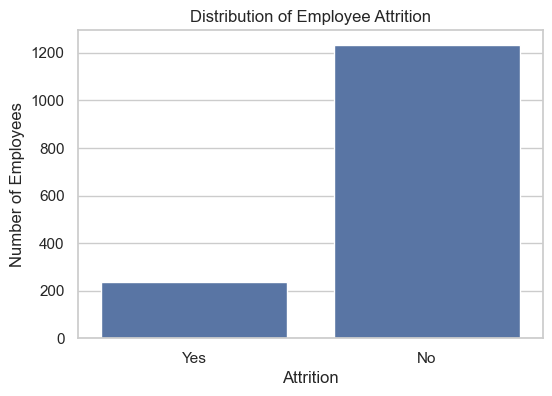

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Attrition")
plt.title("Distribution of Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

### Target Variable Insight

Findings:
- The dataset is imbalanced because more employees stayed than left.
- This is important because later classification models may become biased toward predicting the majority class.
- This confirms why imbalance handling will be needed later in the project.

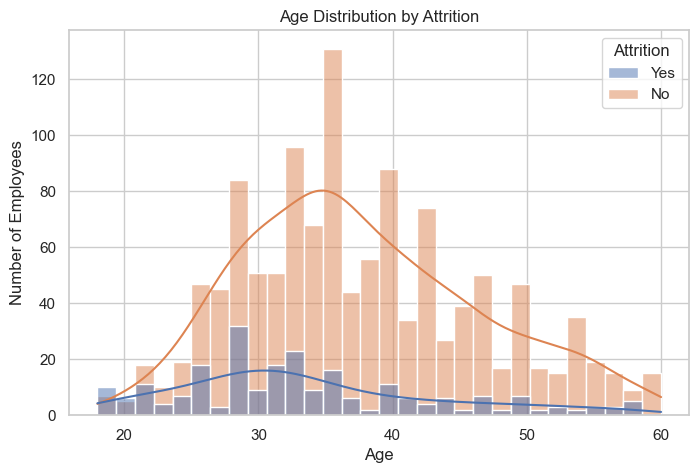

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Attrition", kde=True, bins=30)
plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.show()

### Age Insight

The age distribution shows that employee attrition is more concentrated among younger and mid-career employees, particularly between the ages of approximately 25 and 35. Employees who left the company appear to cluster more heavily within this age range compared with older employees.

As employee age increases, the number of attrition cases generally decreases. Employees above the age of 45 appear less likely to leave the company, which may suggest stronger organisational attachment, greater job stability, higher seniority, or better compensation and benefits.

This pattern suggests that younger employees may be more likely to explore external career opportunities, seek faster salary growth, or change jobs more frequently. It may also indicate that early-career employees are more sensitive to workload, career progression, workplace satisfaction, or work-life balance issues.

The findings suggest that `Age` could become an important predictive feature during later classification modelling and may also help form meaningful employee segments during clustering analysis.

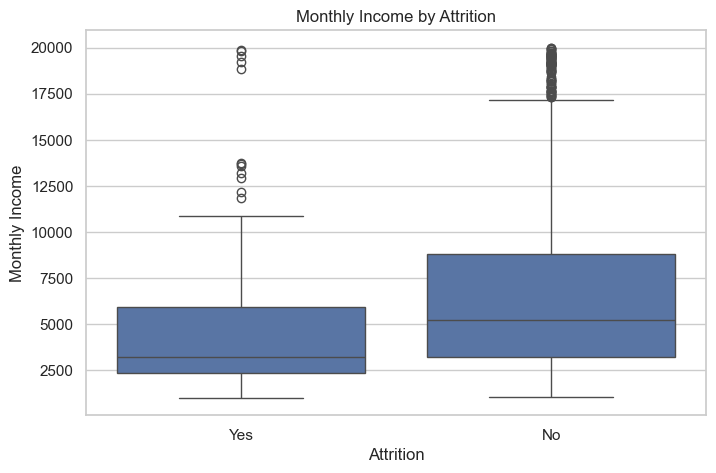

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

### Monthly Income Insight

Findings:
- Employees who left have lower median monthly income compared with employees who stayed.
- This suggests compensation may be linked to attrition risk.

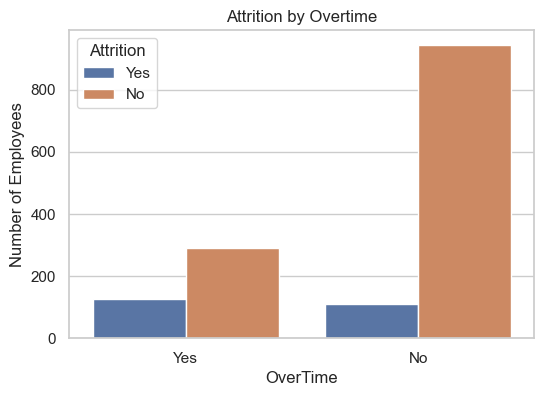

In [29]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Attrition by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()

### Overtime Insight

The visualisation shows a strong relationship between overtime and employee attrition. Employees who work overtime appear significantly more likely to leave the company compared with employees who do not work overtime.

Although the company has more employees who do not work overtime overall, the proportion of attrition cases is noticeably higher among employees working overtime. This suggests that excessive workload, burnout, stress, or poor work-life balance may contribute to employees leaving the organisation.

The findings indicate that `OverTime` may become one of the strongest predictive features during later classification modelling. It may also play an important role in identifying high-risk employee groups during clustering analysis.

From a business perspective, the company may need to investigate workload distribution, staffing levels, and employee wellbeing initiatives to reduce attrition among employees frequently working overtime.

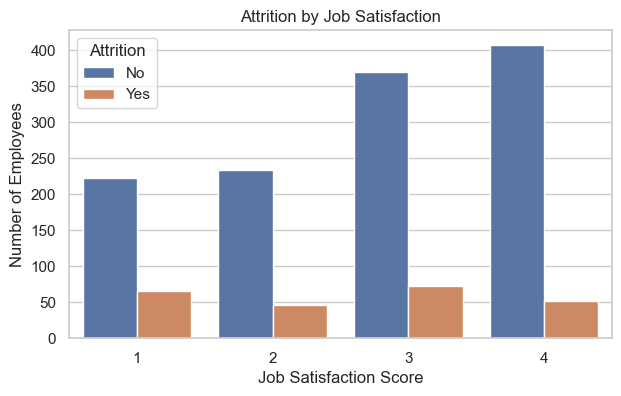

In [30]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")
plt.title("Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Employees")
plt.show()

### Job Satisfaction Insight

The analysis suggests a relationship between job satisfaction and employee attrition. Employees with lower job satisfaction scores appear more likely to leave the company compared with employees reporting higher satisfaction levels.

Attrition cases are particularly noticeable among employees with satisfaction scores of 1 and 2, while employees with higher satisfaction scores generally show lower attrition levels. Although attrition still exists among employees with high satisfaction, the overall proportion appears lower relative to the larger employee population in those categories.

This pattern suggests that employee satisfaction may influence retention and organisational commitment. Employees who are less satisfied may be more likely to seek external opportunities, experience disengagement, or feel disconnected from their work environment.

The findings indicate that `JobSatisfaction` is likely to be an important feature for future predictive modelling and employee segmentation. From a business perspective, improving workplace culture, recognition, career growth opportunities, and employee engagement initiatives may help reduce attrition risk.

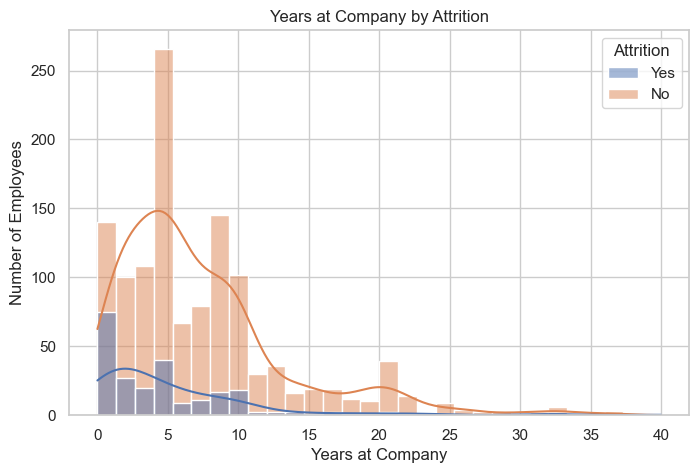

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="YearsAtCompany", hue="Attrition", kde=True, bins=30)
plt.title("Years at Company by Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.show()

### Years at Company Insight

The distribution of years at company suggests that attrition is more common among employees with shorter tenure, particularly during the early years of employment. Employees who left the company appear concentrated within the first few years, while longer-tenured employees show lower attrition levels overall.

This pattern may indicate that the organisation experiences higher turnover among newer employees, possibly due to onboarding challenges, unmet expectations, career mobility, or adjustment difficulties within the company.

As tenure increases, attrition cases become less frequent, which may suggest that employees who remain longer develop stronger organisational attachment, better career stability, and greater commitment to the company.

The findings suggest that `YearsAtCompany` could become an important predictive feature in later classification models and may also help define employee personas during clustering analysis. From a business perspective, the company may benefit from improving early-career employee engagement, onboarding processes, mentorship programmes, and retention strategies during the first few years of employment.

## 10. Initial Cleaning Decisions

The purpose of this stage is not to transform the dataset heavily.  
Instead, I will make basic cleaning decisions that prepare the data for feature engineering in the next stage.

Cleaning checks include:
- Removing duplicate rows if present
- Flagging constant columns
- Confirming missing values
- Preserving the original meaning of the dataset

In [32]:
# Create a copy of the raw dataset before cleaning
df_clean = df.copy()

# Remove duplicate rows if any exist
df_clean = df_clean.drop_duplicates()

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")

Original shape: (1470, 35)
Cleaned shape: (1470, 35)


In [33]:
# Identify constant columns again
constant_columns = [col for col in df_clean.columns if df_clean[col].nunique() == 1]

constant_columns

['EmployeeCount', 'Over18', 'StandardHours']

### Cleaning Decision

- No missing values were found, so no imputation was required.
- No Duplicate rows were found.
- Constant columns such as `EmployeeCount`, `Over18`, and `StandardHours` were flagged because they do not add analytical value.
- I will keep the dataset mostly unchanged at this stage to avoid making premature modelling decisions before feature engineering.

In [34]:
# Save cleaned dataset for the next stage
df_clean.to_csv("hr_attrition_clean_day1.csv", index=False)

print("Cleaned Day 1 dataset saved successfully as hr_attrition_clean_day1.csv")

Cleaned Day 1 dataset saved successfully as hr_attrition_clean_day1.csv


In [35]:
df_clean.to_csv("../data/processed/hr_attrition_clean_day1.csv", index=False)

print("Saved successfully")

Saved successfully


## 11. Day 1 Summary

Today’s work established the foundation for the employee attrition project.

The dataset was loaded, inspected, and pushed into SQLite for SQL-based analysis.  
Initial SQL queries explored attrition by department, overtime, income, and job role.  
Exploratory data analysis was then used to examine the target variable and important features such as age, monthly income, overtime, job satisfaction, and years at company.

The key finding from this foundation stage is that attrition is not random.  
Early patterns suggest that factors such as overtime, income, department, job role, satisfaction, and tenure may help explain why employees leave.

The dataset appears ready for the next stage: feature engineering and encoding.